# Get Dataset


In [ ]:
# import json
# import os
# import requests
# from tqdm import tqdm

# output_dir = "pickleball_coco"
# splits = ["train", "val", "test"]

# coco_data = {
#     split: {
#         "info": {},
#         "licenses": [],
#         "categories": [],
#         "images": [],
#         "annotations": []
#     } for split in splits
# }

# for s in splits:
#     os.makedirs(os.path.join(output_dir, s), exist_ok=True)

# ndjson_file = "preprocessing_dataset/pickleball-court.ndjson"

# print("Processing and loading data in Coco format...") 

# # Biến để tự tạo ID tăng dần cho annotation (vì COCO yêu cầu mỗi object có 1 id riêng)
# ann_id_counter = 1
# image_id_mapping = {}  # Đảm bảo ánh xạ đúng ID ảnh

# with open(ndjson_file, "r", encoding="utf-8") as f:
#     first_line = f.readline().strip()
#     if first_line:
#         meta_base = json.loads(first_line)
#         if meta_base.get("type") == "dataset":
#             for s in splits:
#                 coco_data[s]["info"] = {
#                     "year": meta_base.get("created_at", "2026")[:4],
#                     "version": meta_base.get("version", "latest"),
#                     "description": meta_base.get("name", "Pickleball court"),
#                     "contributor": "Ultralytics",
#                     "date_created": meta_base.get("created_at", "")
#                 }
#                 coco_data[s]["categories"] = [{
#                     "id": 1,
#                     "name": "court",
#                     "supercategory": "sports_facility",
#                     "keypoints": [f"point_{i}" for i in range(meta_base["kpt_shape"][0])],
#                     "skeleton": [] 
#                 }]

#     f.seek(0)
#     for line in tqdm(f):
#         line = line.strip()
#         if not line:
#             continue
            
#         data = json.loads(line)
#         if data.get("type") != "image":
#             continue

#         file_name = data["file"]
#         image_url = data["url"]
#         split = data["split"] 

#         if split not in splits:
#             split = "train" 
            
#         target_folder = os.path.join(output_dir, split)
#         img_path = os.path.join(target_folder, file_name)

#         try:
#             img_data = requests.get(image_url, timeout=10).content
#             with open(img_path, "wb") as img_f:
#                 img_f.write(img_data)
#         except Exception as e:
#             print(f"\nKhông thể tải ảnh {file_name}: {e}")
#             continue

#         current_img_id = len(coco_data[split]["images"])

#         coco_data[split]["images"].append({
#             "id": current_img_id,
#             "file_name": file_name,
#             "width": data["width"],
#             "height": data["height"]
#         })

#         raw_annotations = data.get("annotations", {}).get("pose", [])
#         for ann in raw_annotations:
#             # Dữ liệu gốc: [class_id, x_center, y_center, width, height, px1, py1, pv1...] (Đều đã chuẩn hóa từ 0-1)
#             # COCO yêu cầu tọa độ dạng Pixel (Bbox: [x_min, y_min, width, height], Keypoints: [x, y, v])
#             w_img, h_img = data["width"], data["height"]

#             x_center = ann[1] * w_img
#             y_center = ann[2] * h_img
#             bbox_w = ann[3] * w_img
#             bbox_h = ann[4] * h_img
#             x_min = x_center - (bbox_w / 2)
#             y_min = y_center - (bbox_h / 2)

#             raw_kpts = ann[5:]
#             coco_kpts = []
#             num_keypoints = 0
            
#             for i in range(0, len(raw_kpts), 3):
#                 real_x = raw_kpts[i] * w_img
#                 real_y = raw_kpts[i+1] * h_img
#                 v = int(raw_kpts[i+2]) # Trạng thái hiển thị (0: ko có, 1: bị che, 2: nhìn rõ)
                
#                 coco_kpts.extend([round(real_x, 2), round(real_y, 2), v])
#                 if v > 0:
#                     num_keypoints += 1
            
#             coco_data[split]["annotations"].append({
#                 "id": ann_id_counter,
#                 "image_id": current_img_id,
#                 "category_id": 1, # Lớp 'court'
#                 "bbox": [round(x_min, 2), round(y_min, 2), round(bbox_w, 2), round(bbox_h, 2)],
#                 "area": round(bbox_w * bbox_h, 2),
#                 "keypoints": coco_kpts,
#                 "num_keypoints": num_keypoints,
#                 "iscrowd": 0
#             })
#             ann_id_counter += 1

# for s in splits:
#     # Nếu tập nào không có ảnh (ví dụ file ndjson gốc của bạn thiếu nhãn 'test')
#     # Ta vẫn xuất ra file JSON trống đúng cấu trúc để tránh lỗi cho mô hình ResNet
#     json_out_path = os.path.join(output_dir, s, "_annotations.coco.json")
#     with open(json_out_path, "w", encoding="utf-8") as json_f:
#         json.dump(coco_data[s], json_f, indent=4, ensure_ascii=False)

# print("\n Finish processing !")

# Import library

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import os
import json
import cv2

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Create Torch Dataset

In [4]:
class KeypointsDataset(Dataset):
    def __init__(self, img_dir, data_file):
        self.img_dir = os.path.abspath(img_dir)
        data_file = os.path.abspath(data_file)
        with open(data_file, "r") as f:
            coco_data = json.load(f)

        # Create a mapping from image ID to image filename
        self.image_id_to_filename = {img['id']: img['file_name'] for img in coco_data['images']}
        self.processed_items = []
        for ann in coco_data['annotations']:
            image_id = ann['image_id']
            # Ensure the image exists and has keypoints
            if image_id in self.image_id_to_filename and 'keypoints' in ann:
                image_filename = self.image_id_to_filename[image_id]
                full_img_path = os.path.join(self.img_dir, image_filename)

                # Extract keypoints and remove visibility flags (v) if present
                # COCO keypoints are typically [x1, y1, v1, x2, y2, v2, ...]
                keypoints_with_visibility = ann['keypoints']
                flat_keypoints = []
                for i in range(0, len(keypoints_with_visibility), 3):
                    flat_keypoints.append(keypoints_with_visibility[i])   # x
                    flat_keypoints.append(keypoints_with_visibility[i+1]) # y

                self.processed_items.append({
                    'image_path': full_img_path,
                    'keypoints': np.array(flat_keypoints, dtype=np.float32)
                })

        self.transforms = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.processed_items)

    def __getitem__(self, idx):
        item = self.processed_items[idx]
        img_path = item['image_path']
        img = cv2.imread(img_path)

        if img is None:
            raise FileNotFoundError(f"Image not found at {img_path}")

        h, w = img.shape[:2]

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.transforms(img)
        kps = item['keypoints'].copy() # Get a copy to avoid modifying the stored array

        # Adjust keypoints based on new image dimensions (224x224)
        kps[0::2] = kps[0::2] * (224.0 / w) # Adjust x coordinates
        kps[1::2] = kps[1::2] * (224.0 / h) # Adjust y coordinates

        return img, kps

In [5]:
train_dataset = KeypointsDataset("pickleball_coco/train","pickleball_coco/train/_annotations.coco.json")
val_dataset = KeypointsDataset("pickleball_coco/val","pickleball_coco/val/_annotations.coco.json")
test_dataset = KeypointsDataset("pickleball_coco/test","pickleball_coco/test/_annotations.coco.json")

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)

# Model Resnet50



In [6]:
model = models.resnet50(pretrained=True)
model.fc =  torch.nn.Linear(model.fc.in_features, 14*2) # Replaces the last layer

c:\STUDY\Pre-Thesis\AI Robotics for Pickleball Match\.venv-3.13\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\STUDY\Pre-Thesis\AI Robotics for Pickleball Match\.venv-3.13\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
model = model.to(device)

# Train model

In [8]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [9]:
import torch
import numpy as np

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

epochs = 100
threshold = 10  # pixel threshold

for epoch in range(epochs):

    # ================= TRAIN =================
    model.train()

    running_loss = 0.0
    correct_keypoints = 0
    total_keypoints = 0

    for i, (imgs, kps) in enumerate(train_loader):

        imgs = imgs.to(device)
        kps = kps.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(outputs, kps)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # ===== Accuracy Calculation =====
        preds = outputs.detach().cpu().numpy()
        targets = kps.detach().cpu().numpy()

        preds = preds.reshape(-1, 14, 2)
        targets = targets.reshape(-1, 14, 2)

        distances = np.linalg.norm(preds - targets, axis=2)

        correct_keypoints += np.sum(distances < threshold)
        total_keypoints += distances.size

        if i % 10 == 0:
            print(f"Epoch {epoch+1}, Iter {i}, Loss: {loss.item():.4f}")

    train_loss = running_loss / len(train_loader)
    train_acc = correct_keypoints / total_keypoints

    # ================= VALIDATION =================
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for imgs, kps in val_loader:

            imgs = imgs.to(device)
            kps = kps.to(device)

            outputs = model(imgs)

            loss = criterion(outputs, kps)

            val_running_loss += loss.item()

            preds = outputs.cpu().numpy().reshape(-1, 14, 2)
            targets = kps.cpu().numpy().reshape(-1, 14, 2)

            distances = np.linalg.norm(preds - targets, axis=2)

            val_correct += np.sum(distances < threshold)
            val_total += distances.size

    val_loss = val_running_loss / len(val_loader)
    val_acc = val_correct / val_total

    # ================= SAVE HISTORY =================
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 1, Iter 0, Loss: 15982.5918
Epoch 1, Iter 10, Loss: 13632.5244
Epoch 1, Iter 20, Loss: 13181.7324
Epoch 1, Iter 30, Loss: 13612.6143
Epoch 1, Iter 40, Loss: 13143.0430
Epoch 1, Iter 50, Loss: 13709.8174
Epoch 1, Iter 60, Loss: 12906.0566
Epoch 1, Iter 70, Loss: 11332.1074
Epoch 1, Iter 80, Loss: 12031.7598
Epoch 1, Iter 90, Loss: 11809.6279
Epoch 1, Iter 100, Loss: 10095.6816
Epoch 1, Iter 110, Loss: 10392.0293
Epoch 1, Iter 120, Loss: 10723.2441
Epoch 1, Iter 130, Loss: 9838.8945
Epoch 1, Iter 140, Loss: 9665.4980
Epoch 1, Iter 150, Loss: 10856.5811
Epoch 1, Iter 160, Loss: 8392.1826
Epoch 1, Iter 170, Loss: 8624.7969
Epoch 1, Iter 180, Loss: 9976.7100
Epoch 1, Iter 190, Loss: 9469.5205
Epoch 1, Iter 200, Loss: 8174.8799
Epoch 1, Iter 210, Loss: 7993.3843
Epoch 1, Iter 220, Loss: 7219.4893
Epoch 1, Iter 230, Loss: 7375.6377
Epoch 1, Iter 240, Loss: 6391.5474
Epoch 1, Iter 250, Loss: 6572.4668
Epoch 1, Iter 260, Loss: 5588.6050
Epoch 1, Iter 270, Loss: 5600.5933
Epoch 1, Iter 280

# Save model

In [10]:
torch.save(model.state_dict(), "models/keypoints14_model.pth")

# Performance Evaluation

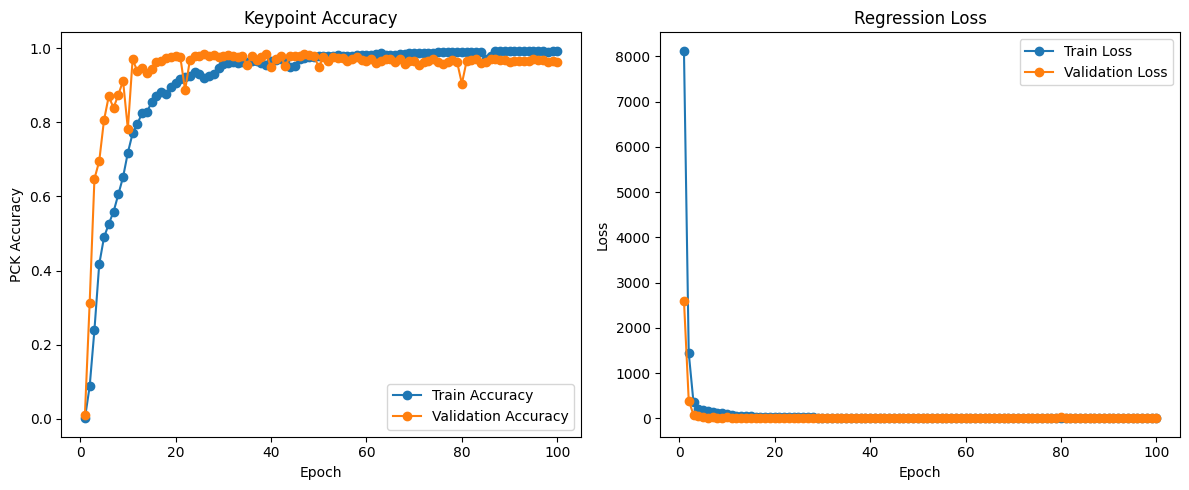

In [11]:
import matplotlib.pyplot as plt

def plot_training(history):

    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)

    plt.plot(epochs, history['train_acc'], marker='o', label='Train Accuracy')
    plt.plot(epochs, history['val_acc'], marker='o', label='Validation Accuracy')

    plt.xlabel("Epoch")
    plt.ylabel("PCK Accuracy")
    plt.title("Keypoint Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)

    plt.plot(epochs, history['train_loss'], marker='o', label='Train Loss')
    plt.plot(epochs, history['val_loss'], marker='o', label='Validation Loss')

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Regression Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training(history)

# Check model with random image


- Set up library

In [12]:
import os
import random
import cv2
import torch
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import torchvision.models as models

Image loaded: C:\STUDY\Pre-Thesis\AI Robotics for Pickleball Match\image\z7872649249939_5c655b92b3d4c6a7729c8af1602a39c0.jpg
Image size: 1317x674


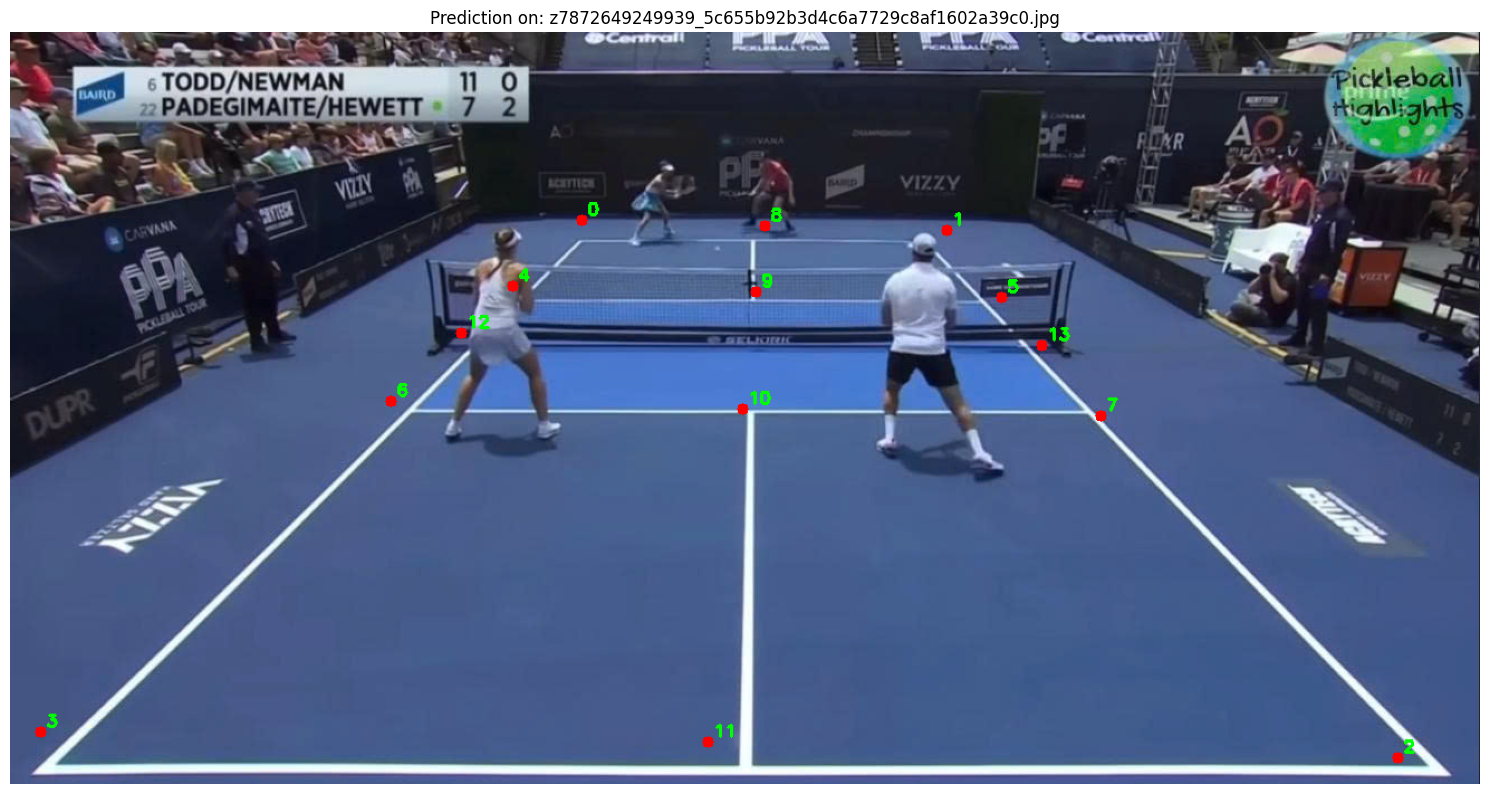

In [13]:
CUSTOM_IMAGE_PATH = r"C:\STUDY\Pre-Thesis\AI Robotics for Pickleball Match\image\z7872649249939_5c655b92b3d4c6a7729c8af1602a39c0.jpg"  # <-- SỬA ĐƯỜNG DẪN NÀY

if not os.path.exists(CUSTOM_IMAGE_PATH):
    print(f"No image found: {CUSTOM_IMAGE_PATH}")
else:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = models.resnet50(weights=None)  # Use weights=None to avoid deprecation warning
    model.fc = torch.nn.Linear(model.fc.in_features, 28)  # 14 keypoints × 2 coordinates

    state_dict = torch.load("models/keypoints14_model.pth", map_location=device)
    model.load_state_dict(state_dict)

    model = model.to(device)
    model.eval()
    
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])
    
    original_img = cv2.imread(CUSTOM_IMAGE_PATH)
    h, w, _ = original_img.shape
    print(f"Image loaded: {CUSTOM_IMAGE_PATH}")
    print(f"Image size: {w}x{h}")
    
    img_pil = Image.fromarray(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    input_tensor = transform(img_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(input_tensor)
    
    kps = outputs.squeeze().cpu().numpy()
    kps[0::2] = kps[0::2] * (w / 224.0)  # X
    kps[1::2] = kps[1::2] * (h / 224.0)  # Y
    
    result_img = original_img.copy()
    for i in range(0, len(kps), 2):
        x, y = int(kps[i]), int(kps[i+1])
        cv2.circle(result_img, (x, y), 5, (0, 0, 255), -1)
        cv2.putText(result_img, str(i//2), (x + 5, y - 5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    plt.figure(figsize=(15, 10))
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Prediction on: {os.path.basename(CUSTOM_IMAGE_PATH)}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # output_path = "custom_output.jpg"
    # cv2.imwrite(output_path, result_img)
    # print(f"Saved result to: {output_path}")